Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['18', '9', '13', '11', '30', '19', '10', '12', '28', '25', '26']
Community 1: ['22', '23', '2', '1', '3', '0']
Community 2: ['15', '16', '14', '20', '17', '27']
Community 3: ['7', '8', '5', '4', '21', '6']



C:\Users\司伟\AppData\Local\Temp\ipykernel_17328\2095804052.py:109: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  edges_draw = nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)


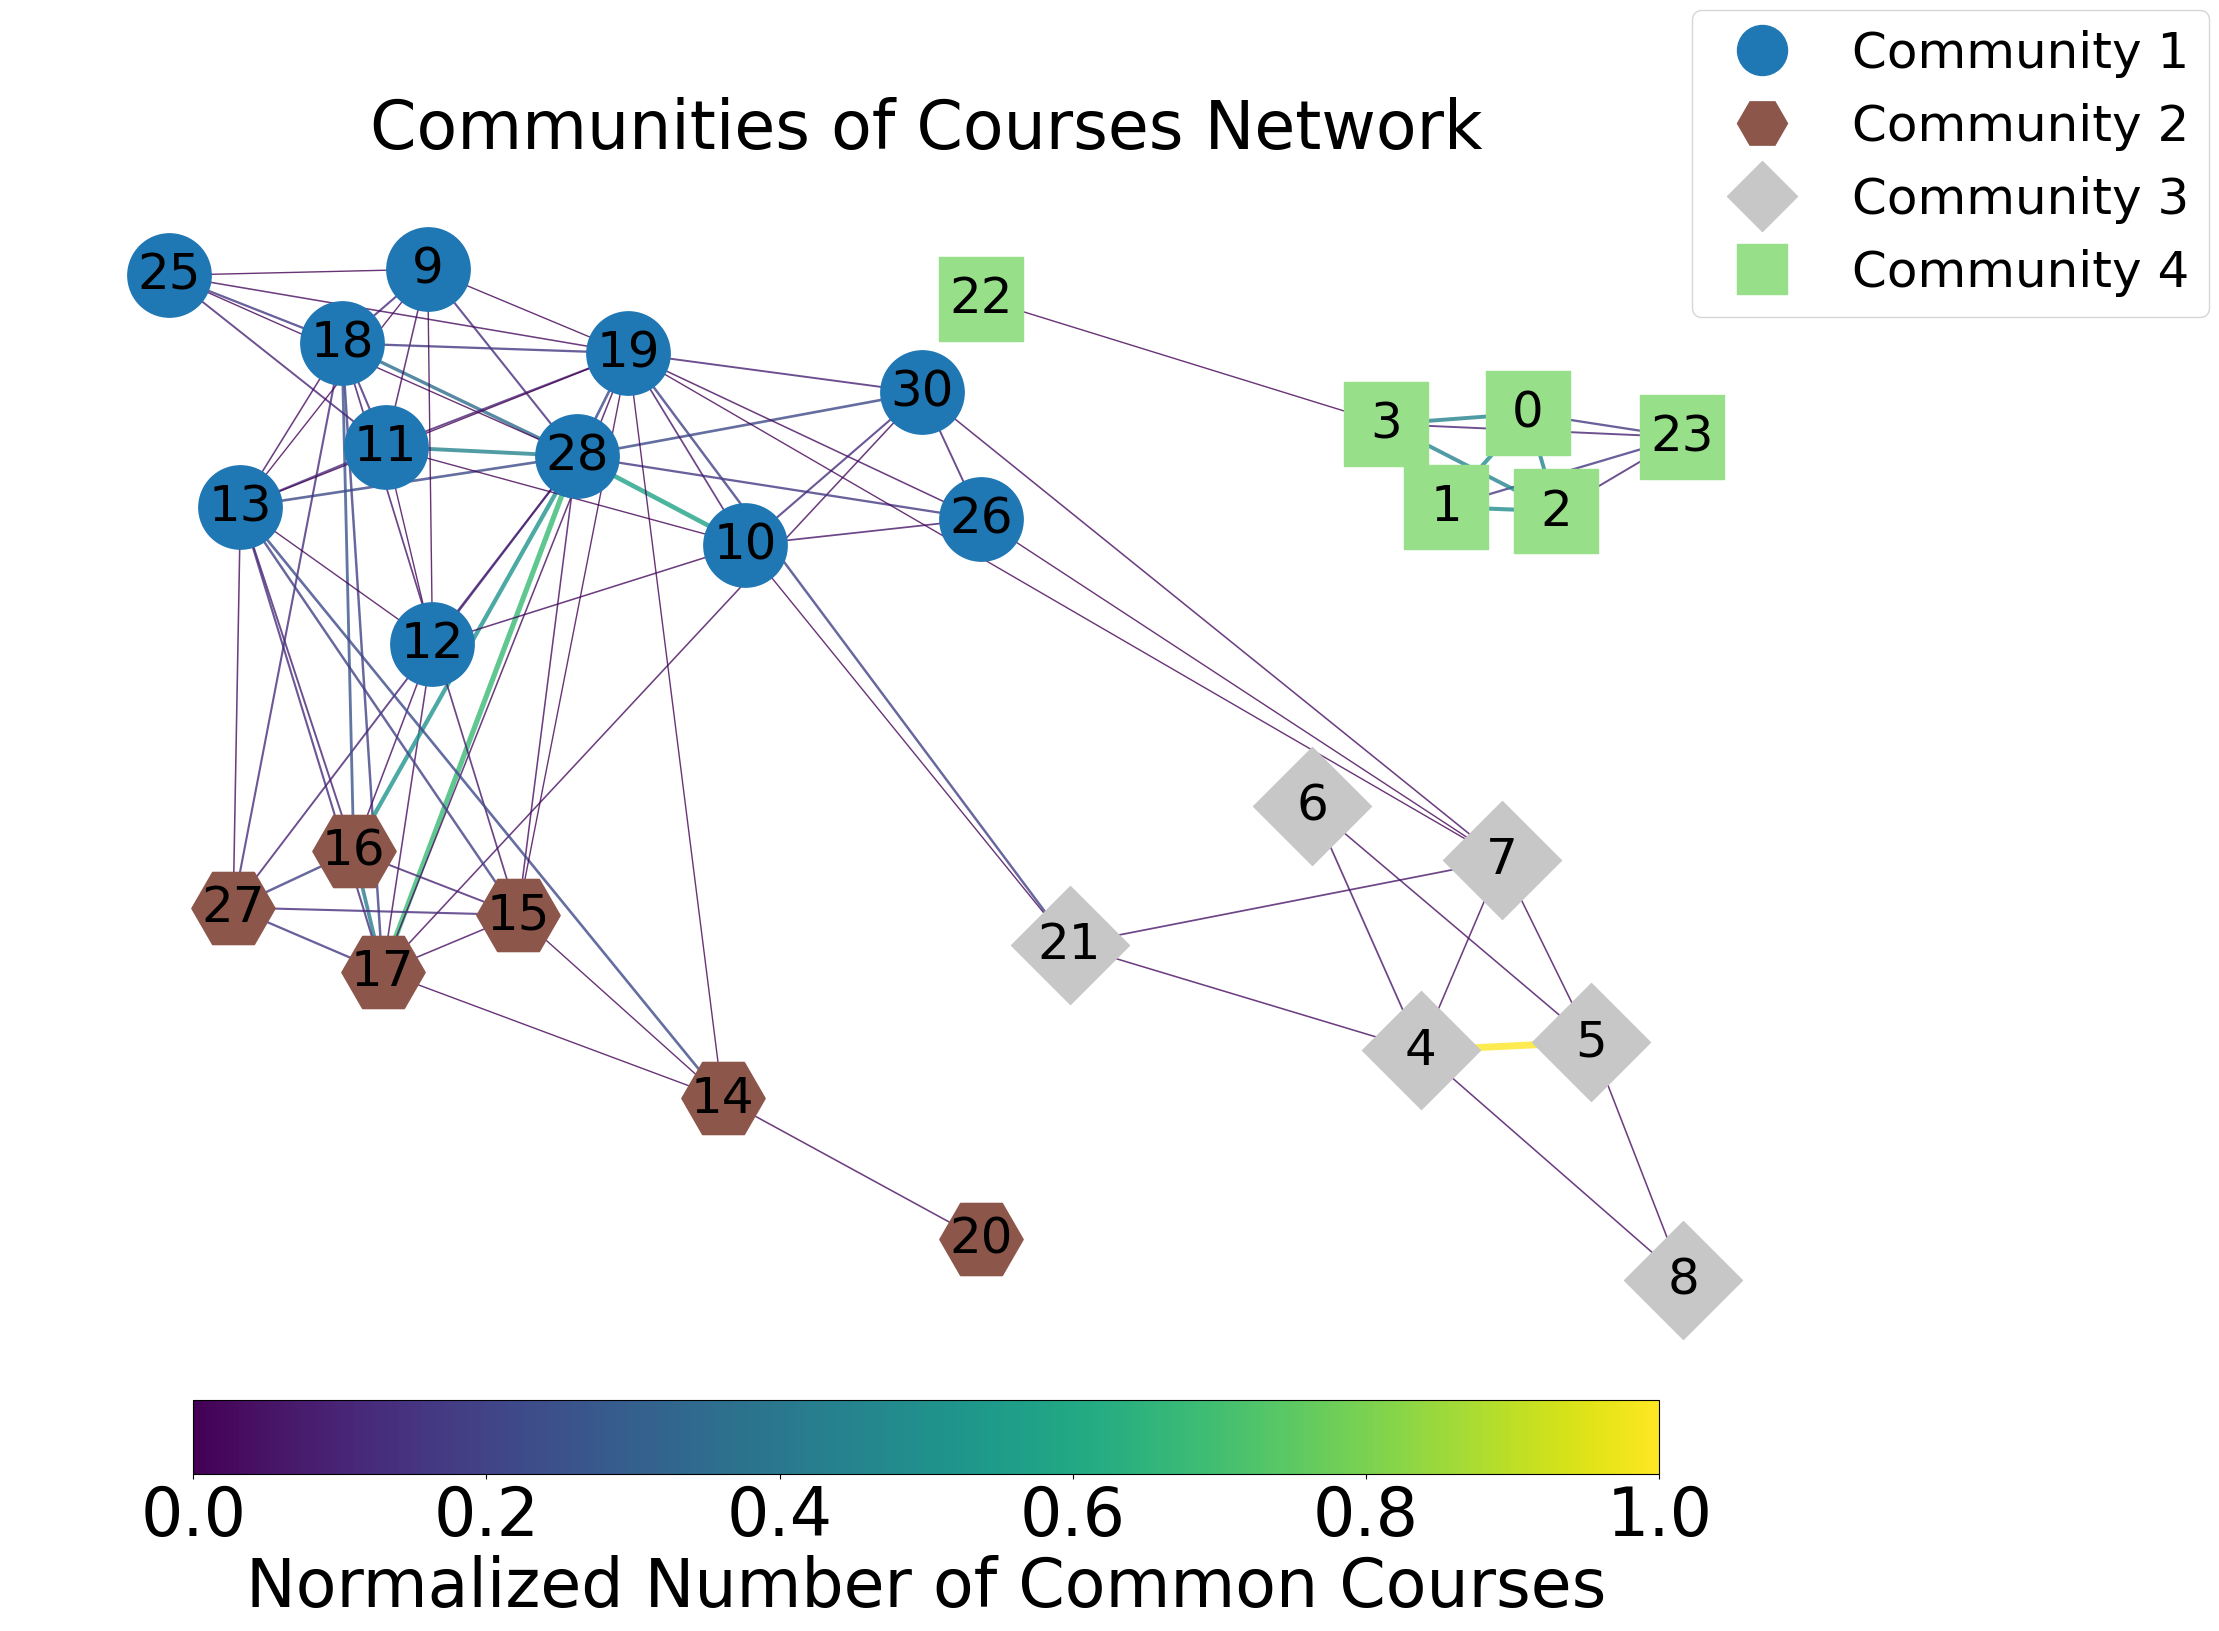

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable, tab20
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import Normalize
from networkx.algorithms.community import greedy_modularity_communities
import math

# 读取图数据，假设每行格式为：学院1 学院2 公共课程数
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 计算加权度中心性
degree_centrality = nx.degree_centrality(G)

# 将节点按度中心性排序
sorted_centrality = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)

# 社区检测
communities = list(greedy_modularity_communities(G))
community_map = {}
for community_index, community in enumerate(communities):
    for node in community:
        community_map[node] = community_index

# 打印社区数量
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()
# 获取节点和度中心性值
nodes = list(degree_centrality.keys())
centrality_values = list(degree_centrality.values())

# 可用形状与颜色（颜色为 tab20）
shapes = ['o', 's', 'H', 'D', 'P', '*', '^', 'v', 'X', '8']
colors = [tab20(i / num_communities) for i in range(num_communities)]

# 设置图形背景为白色
fig, ax = plt.subplots(figsize=(25, 18))

# 布局算法
pos = {}

# 计算网格大小
grid_size = math.ceil(math.sqrt(num_communities))
gap = 2  # 减少社区之间的间距

for i, community in enumerate(communities):
    row = i // grid_size
    col = i % grid_size
    center_x = col * gap
    center_y = -row * gap

    subgraph = G.subgraph(community)
    sub_pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)
    for node, (x, y) in sub_pos.items():
        pos[node] = (center_x + x, center_y + y)

# 绘制节点（不同社团：不同颜色+不同形状）
legend_handles = []
renamed_communities = {0: 'Community 1', 1: 'Community 4', 2: 'Community 2', 3: 'Community 3'}

# 按照新的顺序排列图例
ordered_indices = [0, 2, 3, 1]

for i in ordered_indices:
    shape = shapes[i % len(shapes)]
    color = colors[i % len(colors)]
    nodes_in_community = [n for n in G.nodes() if community_map[n] == i]

    for node in nodes_in_community:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[node],
            node_color=[color],
            node_shape=shape,
            node_size=3600,  # 恢复节点大小
            ax=ax
        )

    legend_handles.append(
        mlines.Line2D([], [], color=color, marker=shape, linestyle='None', markersize=36, label=renamed_communities[i])
    )

# 节点标签
nx.draw_networkx_labels(G, pos, font_size=36, ax=ax)  # 恢复标签字体大小

# 获取边的权重
weights = nx.get_edge_attributes(G, 'weight')
if weights:
    # 将权重标准化到0到1之间
    max_weight = max(weights.values())
    min_weight = min(weights.values())
    norm_weights = {k: (v - min_weight) / (max_weight - min_weight) for k, v in weights.items()}
    
    # 使用颜色渐变范围更大的颜色映射
    edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in G.edges()]
    widths = [1 + norm_weights[edge] * 4 for edge in G.edges()]  # 调整边的宽度范围
    
    # 绘制边
    edges_draw = nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)
    
    # 创建一个虚拟的 ScalarMappable 对象用于显示边权重的颜色条
    sm_edges = ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=1))
    sm_edges.set_array([])
    cbar_edges = plt.colorbar(sm_edges, ax=ax, orientation='horizontal', pad=0.01, shrink=0.8)
    cbar_edges.set_label('Normalized Number of Common Courses', fontsize=48)
    cbar_edges.ax.tick_params(labelsize=48)  # 增大颜色条上数字标签的字体

# 图例设置
ax.legend(handles=legend_handles, title="", fontsize=36, title_fontsize=28, loc='right', bbox_to_anchor=(1.20, 1.0), borderaxespad=0.)

# 设置标题
ax.set_title('Communities of Courses Network', fontsize=48)
ax.set_facecolor('white')  # 设置轴背景为白色
ax.axis('off')

# 紧凑布局并留出空间给标题和图例
plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
plt.savefig("D:/作业合集/数字化市场分析/调整最终.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()




Number of communities: 4


C:\Users\司伟\AppData\Local\Temp\ipykernel_17328\1507788147.py:65: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)
C:\Users\司伟\AppData\Local\Temp\ipykernel_17328\1507788147.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.9])


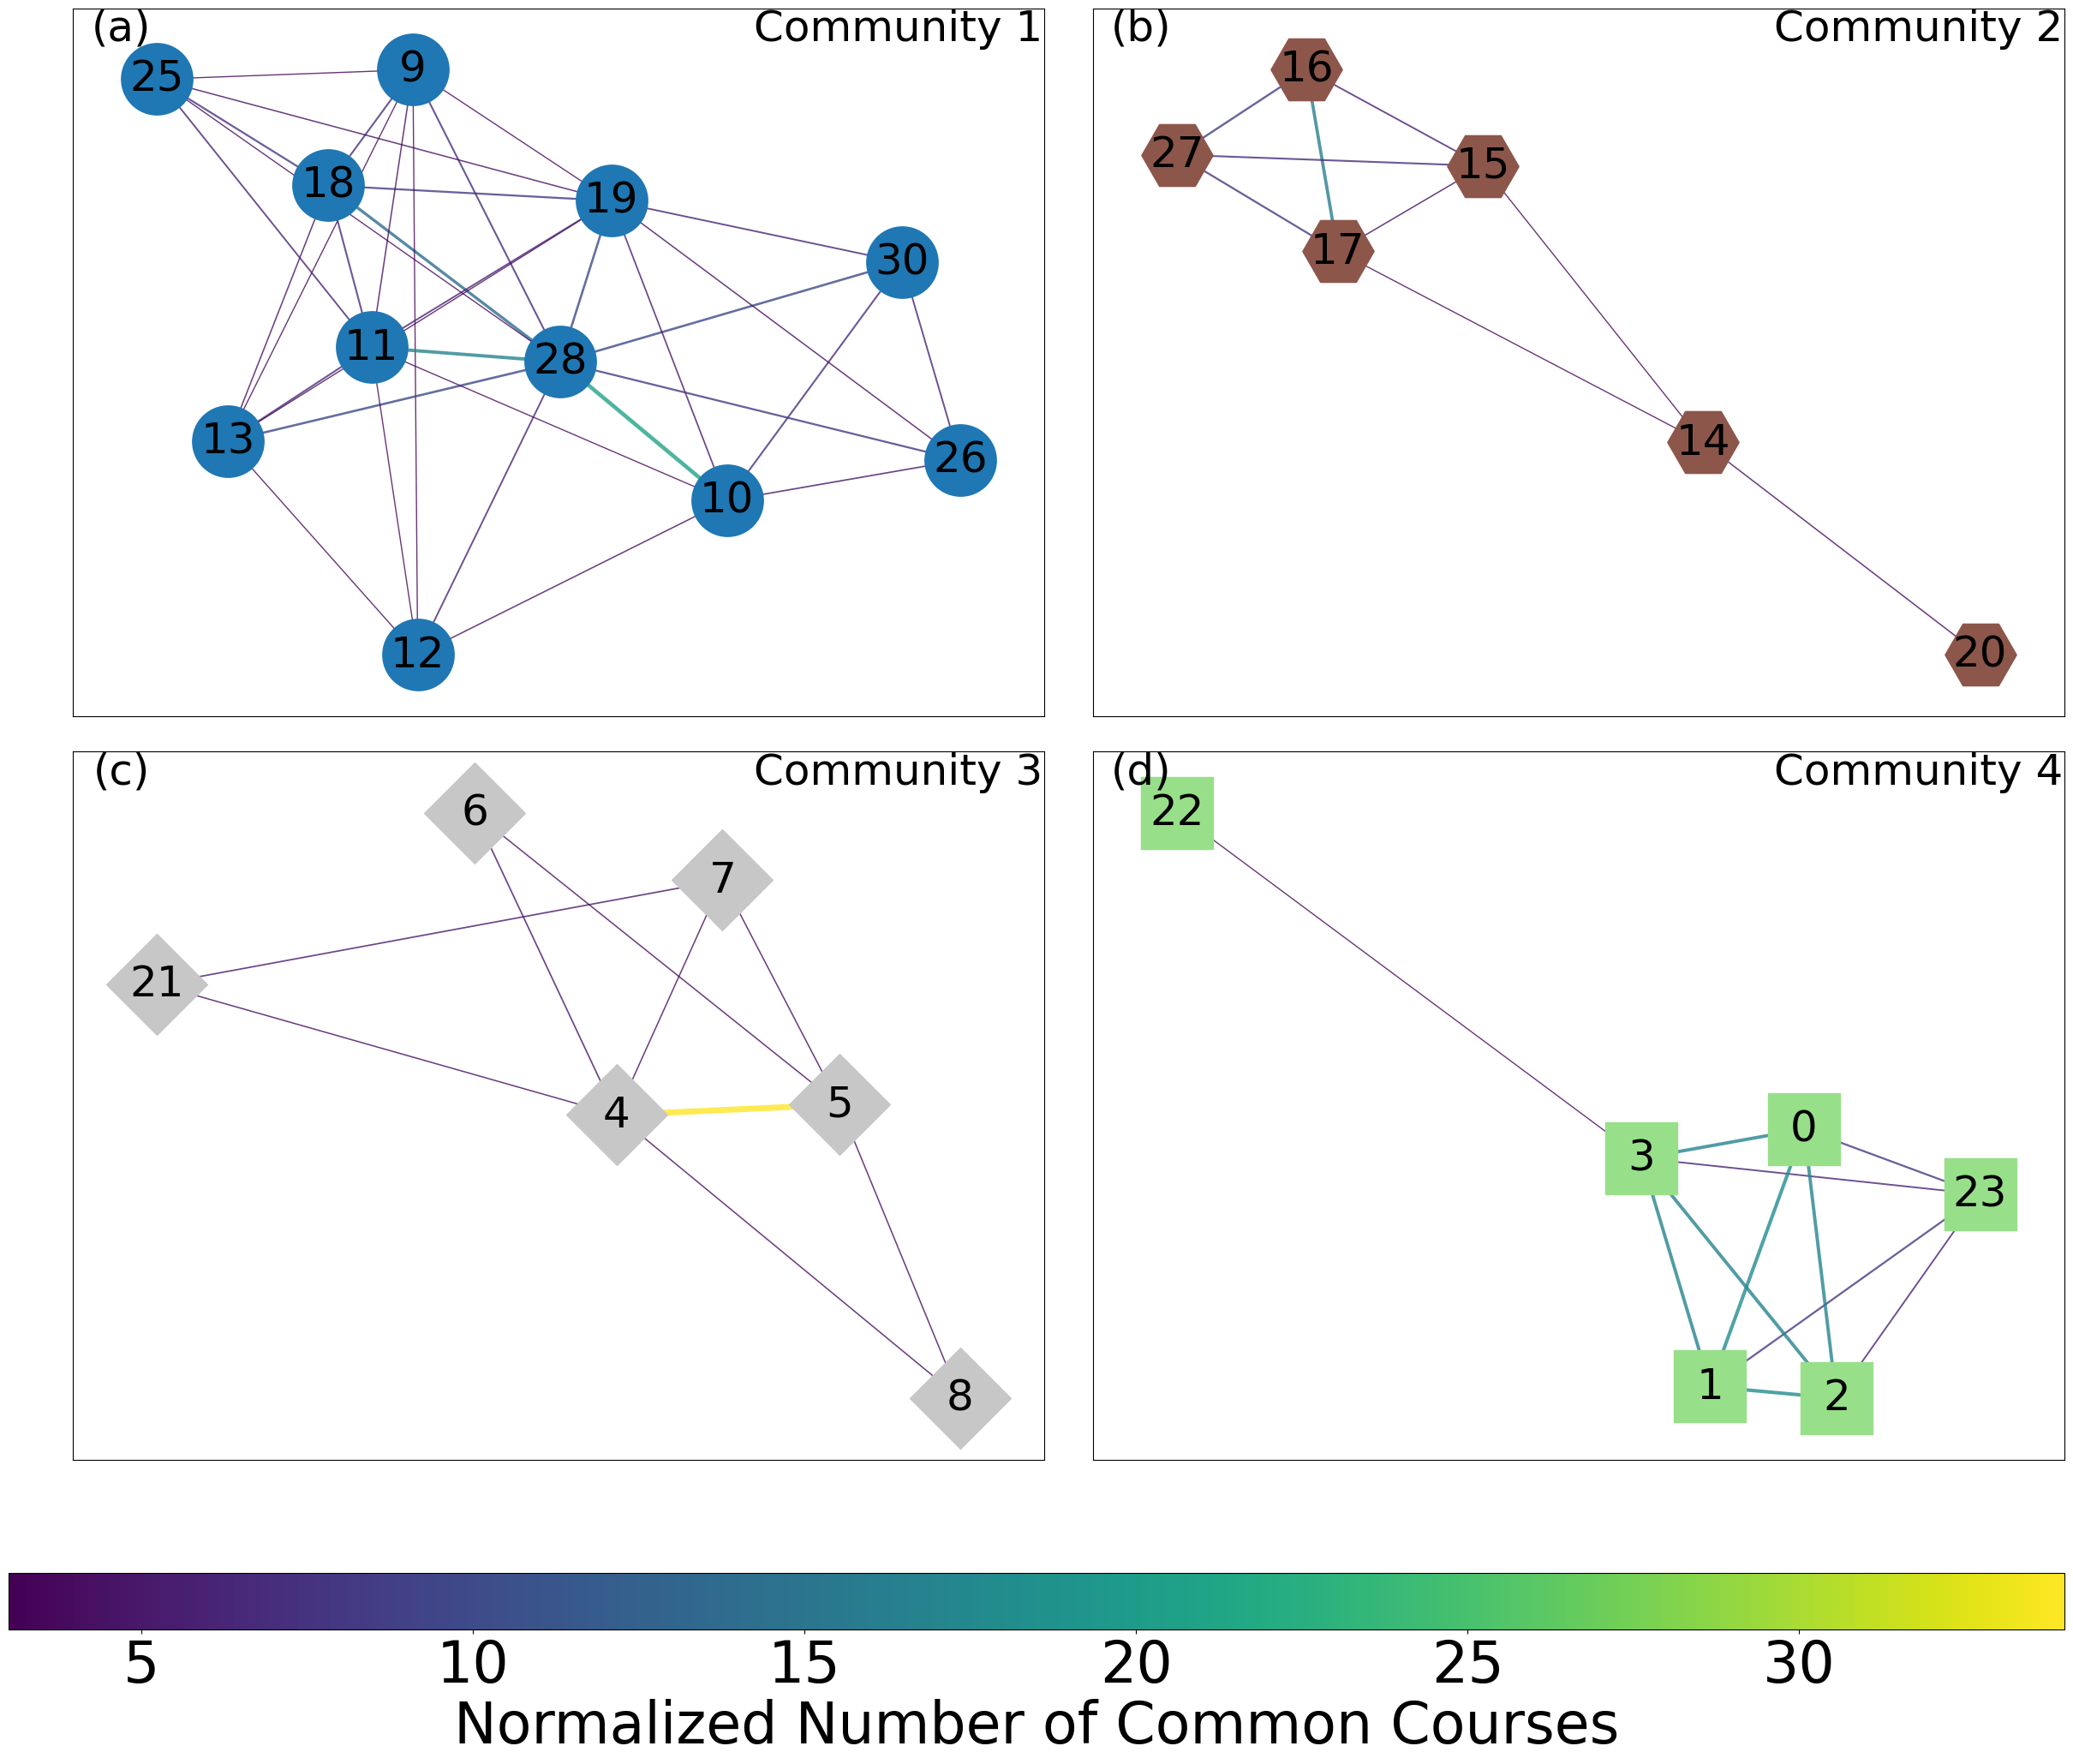

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import tab20
import matplotlib.lines as mlines
from networkx.algorithms.community import greedy_modularity_communities

# 读取图数据
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 社区检测
communities = list(greedy_modularity_communities(G))
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

if num_communities != 4:
    raise ValueError("社区数量不是4个！")

# 社区编号映射
community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i


# 颜色和形状
shapes = ['o', 's', 'H', 'D']
colors = [tab20(i / num_communities) for i in range(num_communities)]

# 自定义社区绘制顺序和标签
ordered_indices = [0, 2, 3, 1]  # 调整显示顺序
renamed_communities = {0: 'Community 1', 1: 'Community 4', 2: 'Community 2', 3: 'Community 3'}

# 计算全局最大最小边权重，确保颜色统一
all_weights = []
for community in communities:
    w = nx.get_edge_attributes(G.subgraph(community), 'weight').values()
    all_weights.extend(w)
global_min_weight = min(all_weights)
global_max_weight = max(all_weights)

# 创建4子图
fig, axes = plt.subplots(2, 2, figsize=(30, 22), gridspec_kw={'wspace':0.05, 'hspace':0.05})

for plot_idx, community_idx in enumerate(ordered_indices):
    row = plot_idx // 2
    col = plot_idx % 2
    ax = axes[row, col]

    community_nodes = [n for n in G.nodes() if community_map[n] == community_idx]
    subgraph = G.subgraph(community_nodes)

    # 社区内部布局
    pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)

    # 绘制社区内部边，使用全局边权归一化
    weights = nx.get_edge_attributes(subgraph, 'weight')
    if weights:
        norm_weights = {
            edge: (weight - global_min_weight) / (global_max_weight - global_min_weight)
            for edge, weight in weights.items()
        }
        edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in subgraph.edges()]
        widths = [1 + norm_weights[edge] * 4 for edge in subgraph.edges()]
        nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)

    # 绘制节点
    color = colors[community_idx]
    shape = shapes[community_idx]
    nx.draw_networkx_nodes(subgraph, pos,
                           node_color=[color],
                           node_shape=shape,
                           node_size=3600,
                           ax=ax)

    # 绘制标签
    nx.draw_networkx_labels(subgraph, pos, font_size=36, ax=ax)

   
    ax.text(0.85, 1.0, renamed_communities[community_idx],
            transform=ax.transAxes,
            fontsize=36, ha='center', va='top',)

    # 单独在下方加上 (a)/(b)/(c)/(d)，字号更大
    subplot_labels = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.05, 1.0, subplot_labels[plot_idx],
            transform=ax.transAxes,
            fontsize=36, ha='center', va='top', )




# 添加统一颜色条
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                           norm=mcolors.Normalize(vmin=global_min_weight, vmax=global_max_weight))
sm.set_array([])

cbar_ax = fig.add_axes([0.1, 0.02, 0.8, 0.03])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Normalized Number of Common Courses', fontsize=48)
cbar.ax.tick_params(labelsize=48)

# 图例
#legend_handles = []
#for i in ordered_indices:
    #legend_handles.append(
        #mlines.Line2D([], [], color=colors[i], marker=shapes[i], linestyle='None',
                      #markersize=20, label=renamed_communities[i])
    #)
#fig.legend(handles=legend_handles, fontsize=36, title_fontsize=28,
           #loc='upper center', bbox_to_anchor=(0.5, 1.05), borderaxespad=0.)

plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.savefig("D:/作业合集/数字化市场分析/四宫图8.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()


Number of communities: 4


C:\Users\司伟\AppData\Local\Temp\ipykernel_29764\3340932576.py:65: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)
C:\Users\司伟\AppData\Local\Temp\ipykernel_29764\3340932576.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.9])


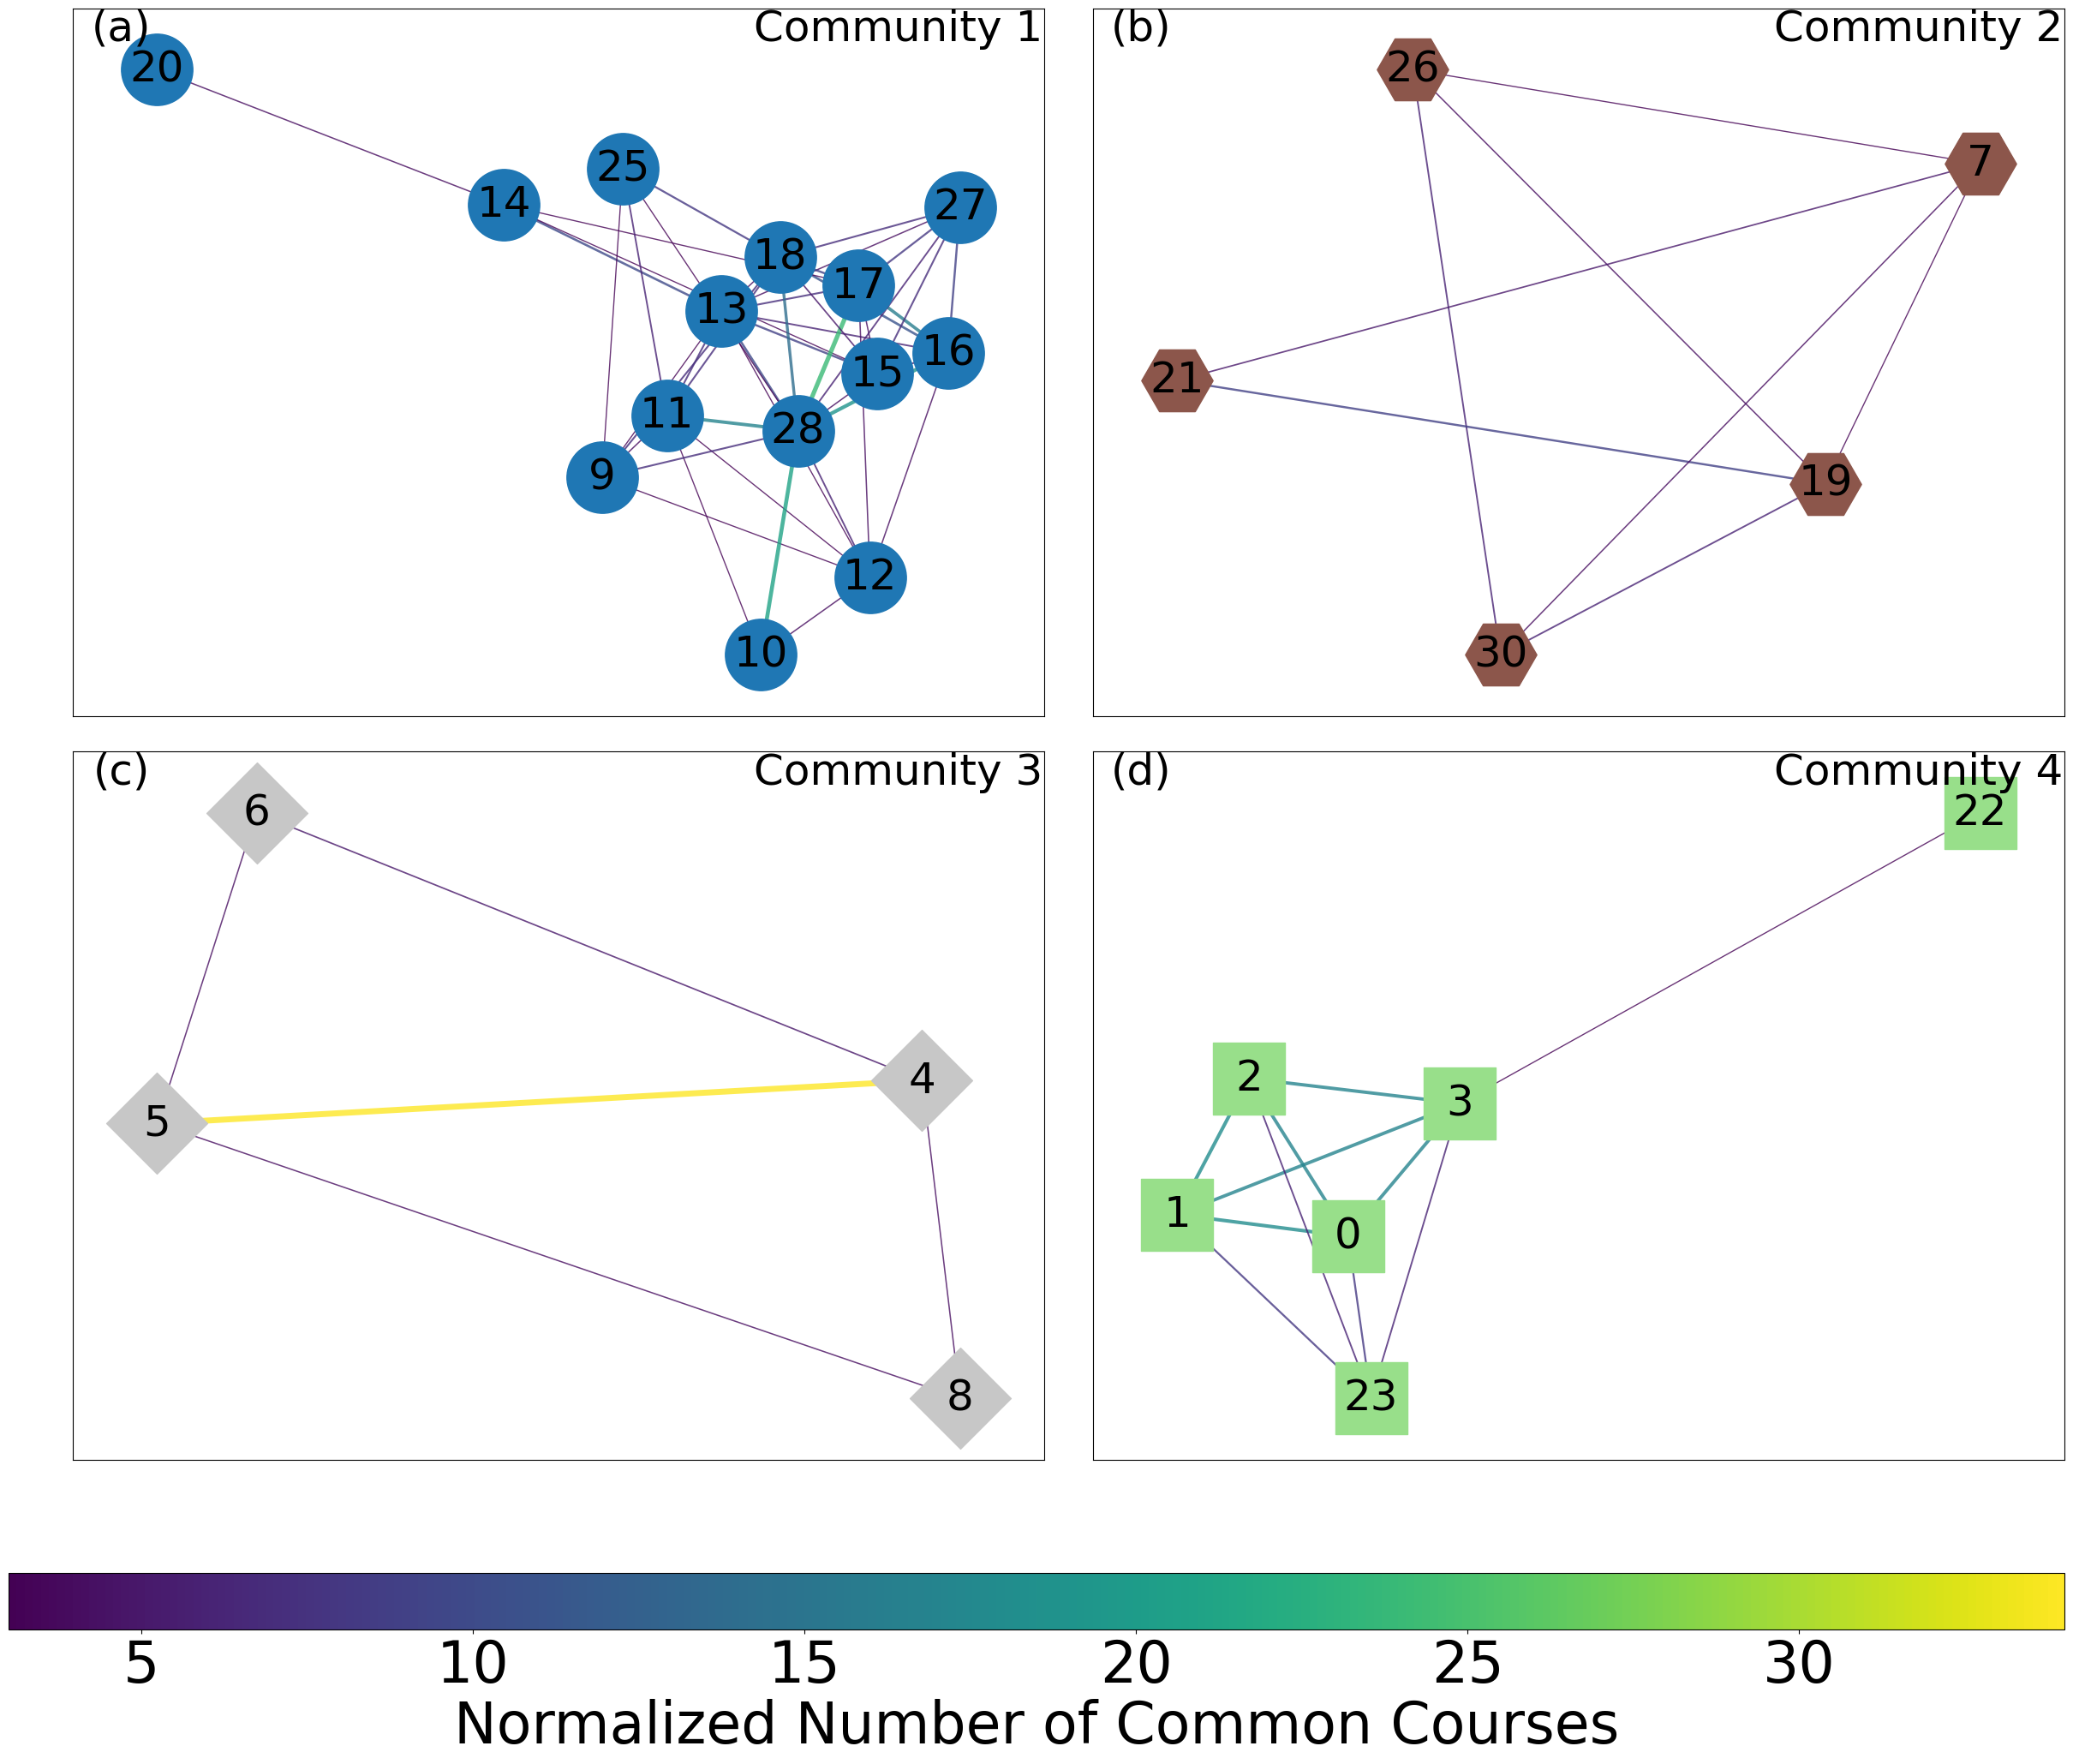

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import tab20
import matplotlib.lines as mlines
from networkx.algorithms.community import greedy_modularity_communities

# 读取图数据
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 社区检测
communities = list(greedy_modularity_communities(G,weight='weight'))
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

if num_communities != 4:
    raise ValueError("社区数量不是4个！")

# 社区编号映射
community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i


# 颜色和形状
shapes = ['o', 's', 'H', 'D']
colors = [tab20(i / num_communities) for i in range(num_communities)]

# 自定义社区绘制顺序和标签
ordered_indices = [0, 2, 3, 1]  # 调整显示顺序
renamed_communities = {0: 'Community 1', 1: 'Community 4', 2: 'Community 2', 3: 'Community 3'}

# 计算全局最大最小边权重，确保颜色统一
all_weights = []
for community in communities:
    w = nx.get_edge_attributes(G.subgraph(community), 'weight').values()
    all_weights.extend(w)
global_min_weight = min(all_weights)
global_max_weight = max(all_weights)

# 创建4子图
fig, axes = plt.subplots(2, 2, figsize=(30, 22), gridspec_kw={'wspace':0.05, 'hspace':0.05})

for plot_idx, community_idx in enumerate(ordered_indices):
    row = plot_idx // 2
    col = plot_idx % 2
    ax = axes[row, col]

    community_nodes = [n for n in G.nodes() if community_map[n] == community_idx]
    subgraph = G.subgraph(community_nodes)

    # 社区内部布局
    pos = nx.spring_layout(subgraph, seed=42, k=0.75, iterations=50)

    # 绘制社区内部边，使用全局边权归一化
    weights = nx.get_edge_attributes(subgraph, 'weight')
    if weights:
        norm_weights = {
            edge: (weight - global_min_weight) / (global_max_weight - global_min_weight)
            for edge, weight in weights.items()
        }
        edge_colors = [plt.cm.viridis(norm_weights[edge]) for edge in subgraph.edges()]
        widths = [1 + norm_weights[edge] * 4 for edge in subgraph.edges()]
        nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, width=widths, alpha=0.8, ax=ax)

    # 绘制节点
    color = colors[community_idx]
    shape = shapes[community_idx]
    nx.draw_networkx_nodes(subgraph, pos,
                           node_color=[color],
                           node_shape=shape,
                           node_size=3600,
                           ax=ax)

    # 绘制标签
    nx.draw_networkx_labels(subgraph, pos, font_size=36, ax=ax)

   
    ax.text(0.85, 1.0, renamed_communities[community_idx],
            transform=ax.transAxes,
            fontsize=36, ha='center', va='top',)

    # 单独在下方加上 (a)/(b)/(c)/(d)，字号更大
    subplot_labels = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.05, 1.0, subplot_labels[plot_idx],
            transform=ax.transAxes,
            fontsize=36, ha='center', va='top', )




# 添加统一颜色条
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                           norm=mcolors.Normalize(vmin=global_min_weight, vmax=global_max_weight))
sm.set_array([])

cbar_ax = fig.add_axes([0.1, 0.02, 0.8, 0.03])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Normalized Number of Common Courses', fontsize=48)
cbar.ax.tick_params(labelsize=48)

# 图例
#legend_handles = []
#for i in ordered_indices:
    #legend_handles.append(
        #mlines.Line2D([], [], color=colors[i], marker=shapes[i], linestyle='None',
                      #markersize=20, label=renamed_communities[i])
    #)
#fig.legend(handles=legend_handles, fontsize=36, title_fontsize=28,
           #loc='upper center', bbox_to_anchor=(0.5, 1.05), borderaxespad=0.)

plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.savefig("D:/作业合集/数字化市场分析/论文/11.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()
